# Step Counter - Exploratory Data Analysis

This notebook explores the OxWalk accelerometer dataset for step counting algorithm development.

Data DOI: 10.5287/bodleian:ORQ2abnbR

Data description
- 39 participants with hip-worn accelerometer data at 100 Hz and +/- 8g with annotated steps
- One Axivity AX3 accelerometer, cliped at the beltline, laterally above the dominant leg
- Positive X axis approximately aligned in the superior direction (towards head)
- Positive Y axis aligned to face anteriorly (towards front)
- Z axis is aligned in the lateral direction (left to right)

In [12]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load data

data_path = Path('../data/OxWalk_Dec2022/Hip_100Hz')
metadata_path = Path('../data/OxWalk_Dec2022/metadata.csv')

# Load metadata
metadata = pd.read_csv(metadata_path)
print(f'Total participants: {len(metadata)}')
print(metadata.head())

Total participants: 39
  participant sex    age
0         P01   M  19-30
1         P02   F  45-81
2         P03   M  31-44
3         P04   F  31-44
4         P05   F  45-81


In [3]:
# Example test subject

sample_file = data_path / 'P01_hip100.csv'
df_sample = pd.read_csv(sample_file)
df_sample['timestamp'] = pd.to_datetime(df_sample['timestamp'])

print(f'Shape: {df_sample.shape}')
print(f'Columns: {df_sample.columns.tolist()}')
print(f'\nFirst few rows:')
print(df_sample.head(10))

Shape: (359999, 5)
Columns: ['timestamp', 'x', 'y', 'z', 'annotation']

First few rows:
                timestamp         x         y         z  annotation
0 2019-07-22 14:42:56.338  0.999302  0.209971 -0.056493           0
1 2019-07-22 14:42:56.348  0.999302  0.219931 -0.056493           0
2 2019-07-22 14:42:56.358  1.001408  0.228453 -0.056493           0
3 2019-07-22 14:42:56.368  0.991524  0.228548 -0.056493           0
4 2019-07-22 14:42:56.380  0.981246  0.219577 -0.056493           0
5 2019-07-22 14:42:56.390  0.984961  0.208591 -0.054932           0
6 2019-07-22 14:42:56.400  0.977690  0.212165 -0.062284           0
7 2019-07-22 14:42:56.410  0.964092  0.205848 -0.074929           0
8 2019-07-22 14:42:56.420  0.971895  0.192812 -0.072553           0
9 2019-07-22 14:42:56.430  0.985590  0.195739 -0.072553           0


In [4]:
# Basic statistics from the example test subject

print('Data Summary:')
print(df_sample.describe())
print(f'\nTotal steps annotated: {df_sample['annotation'].sum()}')
print(
    f'Recording duration: {(df_sample['timestamp'].max() - df_sample['timestamp'].min()).total_seconds():.1f} seconds')
print(
    f'Sampling rate: {len(df_sample) / (df_sample['timestamp'].max() - df_sample['timestamp'].min()).total_seconds():.1f} Hz')

Data Summary:
                           timestamp              x              y  \
count                         359999  359999.000000  359999.000000   
mean   2019-07-22 15:12:56.329321472       0.838438       0.422598   
min       2019-07-22 14:42:56.338000      -5.697851      -1.821399   
25%    2019-07-22 14:57:56.332999936       0.778791       0.244134   
50%       2019-07-22 15:12:56.328000       0.780389       0.524134   
75%    2019-07-22 15:27:56.323500032       0.858231       0.559428   
max       2019-07-22 15:42:56.319000       5.712840       1.735609   
std                              NaN       0.183764       0.230687   

                   z     annotation  
count  359999.000000  359999.000000  
mean       -0.229901       0.002408  
min        -6.144524       0.000000  
25%        -0.304278       0.000000  
50%        -0.275988       0.000000  
75%        -0.160204       0.000000  
max         5.640705       1.000000  
std         0.124598       0.049016  

Total steps 

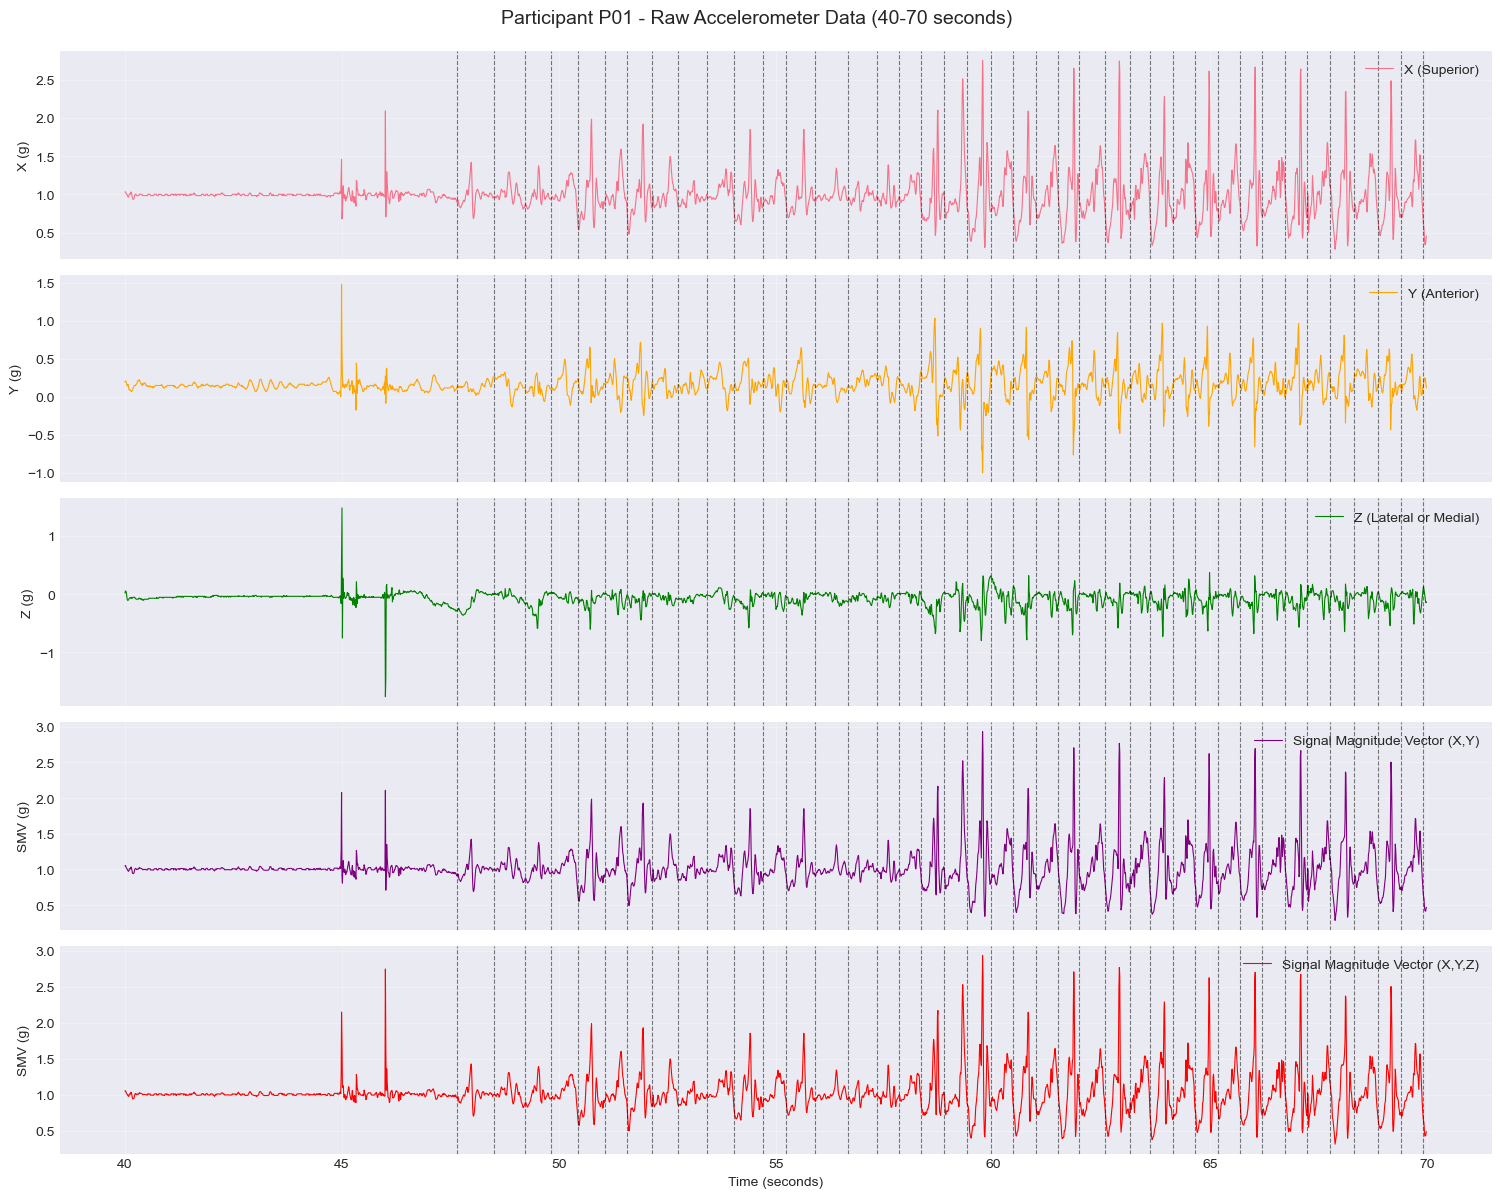

In [21]:
# Visualize raw accelerometer signal for the example test subject

fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

# Plot time window
start_time = 40  # seconds
end_time = 70  # seconds
mask = ((df_sample['timestamp'] - df_sample['timestamp'].min()).dt.total_seconds() >= start_time) & \
       ((df_sample['timestamp'] - df_sample['timestamp'].min()).dt.total_seconds() < end_time)

time_rel = (df_sample.loc[mask, 'timestamp'] - df_sample['timestamp'].min()).dt.total_seconds()

# X, Y, Z axes
axes[0].plot(time_rel, df_sample.loc[mask, 'x'], label='X (Superior)', linewidth=0.8)
axes[0].set_ylabel('X (g)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_rel, df_sample.loc[mask, 'y'], label='Y (Anterior)', color='orange', linewidth=0.8)
axes[1].set_ylabel('Y (g)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_rel, df_sample.loc[mask, 'z'], label='Z (Lateral or Medial)', color='green', linewidth=0.8)
axes[2].set_ylabel('Z (g)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# Signal Magnitude Vector (SMV) of XY
smv_xy = np.sqrt(df_sample['x'] ** 2 + df_sample['y'] ** 2)
axes[3].plot(time_rel, smv_xy[mask], label='Signal Magnitude Vector (X,Y)', color='purple', linewidth=0.8)
axes[3].set_ylabel('SMV (g)')
axes[3].legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

# Signal Magnitude Vector (SMV) of XYZ
smv = np.sqrt(df_sample['x'] ** 2 + df_sample['y'] ** 2 + df_sample['z'] ** 2)
axes[4].plot(time_rel, smv[mask], label='Signal Magnitude Vector (X,Y,Z)', color='red', linewidth=0.8)
axes[4].set_ylabel('SMV (g)')
axes[4].set_xlabel('Time (seconds)')
axes[4].legend(loc='upper right')
axes[4].grid(True, alpha=0.3)

# Mark step annotations with vertical lines
step_mask = df_sample.loc[mask, 'annotation'] == 1
step_times = time_rel[step_mask]
for ax in axes:
    for step_time in step_times:
        ax.axvline(step_time, color='black', linestyle='--', alpha=0.5, linewidth=0.8)

plt.suptitle(f'Participant P01 - Raw Accelerometer Data ({start_time}-{end_time} seconds)', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


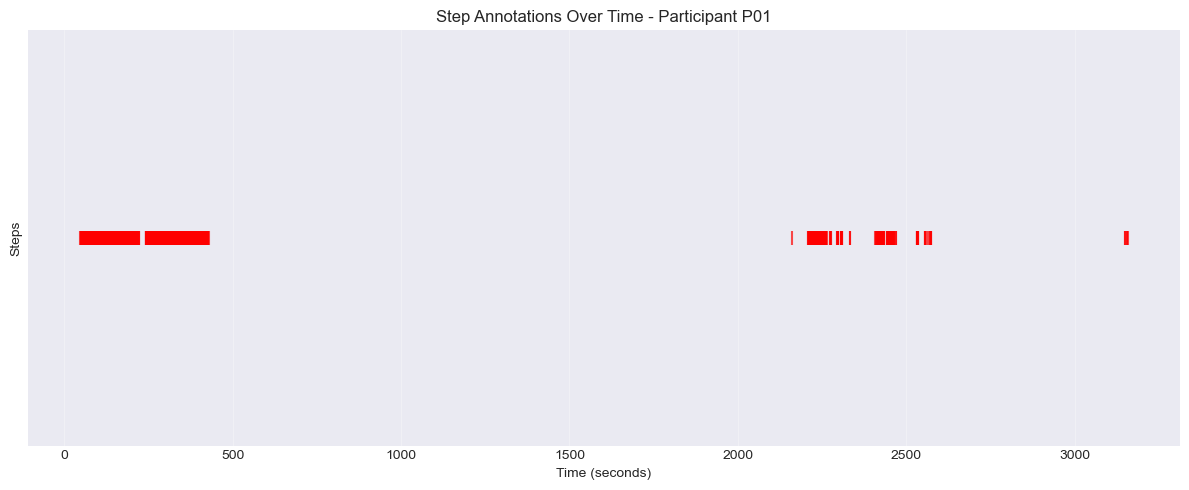

In [22]:
# Step annotation distribution for the example test subject

fig, ax = plt.subplots(figsize=(12, 5))
step_indices = df_sample[df_sample['annotation'] == 1].index
time_rel_all = (df_sample['timestamp'] - df_sample['timestamp'].min()).dt.total_seconds()

ax.scatter(time_rel_all[step_indices], [1] * len(step_indices), marker='|', s=100, color='red', alpha=0.7)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Steps')
ax.set_title('Step Annotations Over Time - Participant P01')
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Load all test subjects

def load_participant_data(participant_id):
    """Load data for a specific participant"""

    file_path = data_path / f'{participant_id}_hip100.csv'
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df


# Load summary statistics for all participants
participant_stats = []

for idx, row in metadata.iterrows():
    pid = row['participant']
    try:
        df = load_participant_data(pid)
        duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
        step_count = df['annotation'].sum()

        # Append a dict of the metadata and measurement data statistics
        participant_stats.append({
            'participant': pid,
            'sex': row['sex'],
            'age': row['age'],
            'duration_sec': duration,
            'step_count': step_count,
            'steps_per_min': (step_count / duration) * 60 if duration > 0 else 0
        })
    except Exception as e:
        print(f"Error loading {pid}: {e}")

stats_df = pd.DataFrame(participant_stats)
print(stats_df.head(10))

  participant sex    age  duration_sec  step_count  steps_per_min
0         P01   M  19-30      3599.981         867      14.450076
1         P02   F  45-81      3599.990         477       7.950022
2         P03   M  31-44      3600.000        4144      69.066667
3         P04   F  31-44      3599.980         213       3.550020
4         P05   F  45-81      3599.990         528       8.800024
5         P06   M  31-44      3599.981         441       7.350039
6         P07   M  19-30      3599.990        2368      39.466776
7         P08   M  45-81      3599.961         382       6.366736
8         P09   M  19-30      3599.990         431       7.183353
9         P10   M  31-44      3599.990         282       4.700013


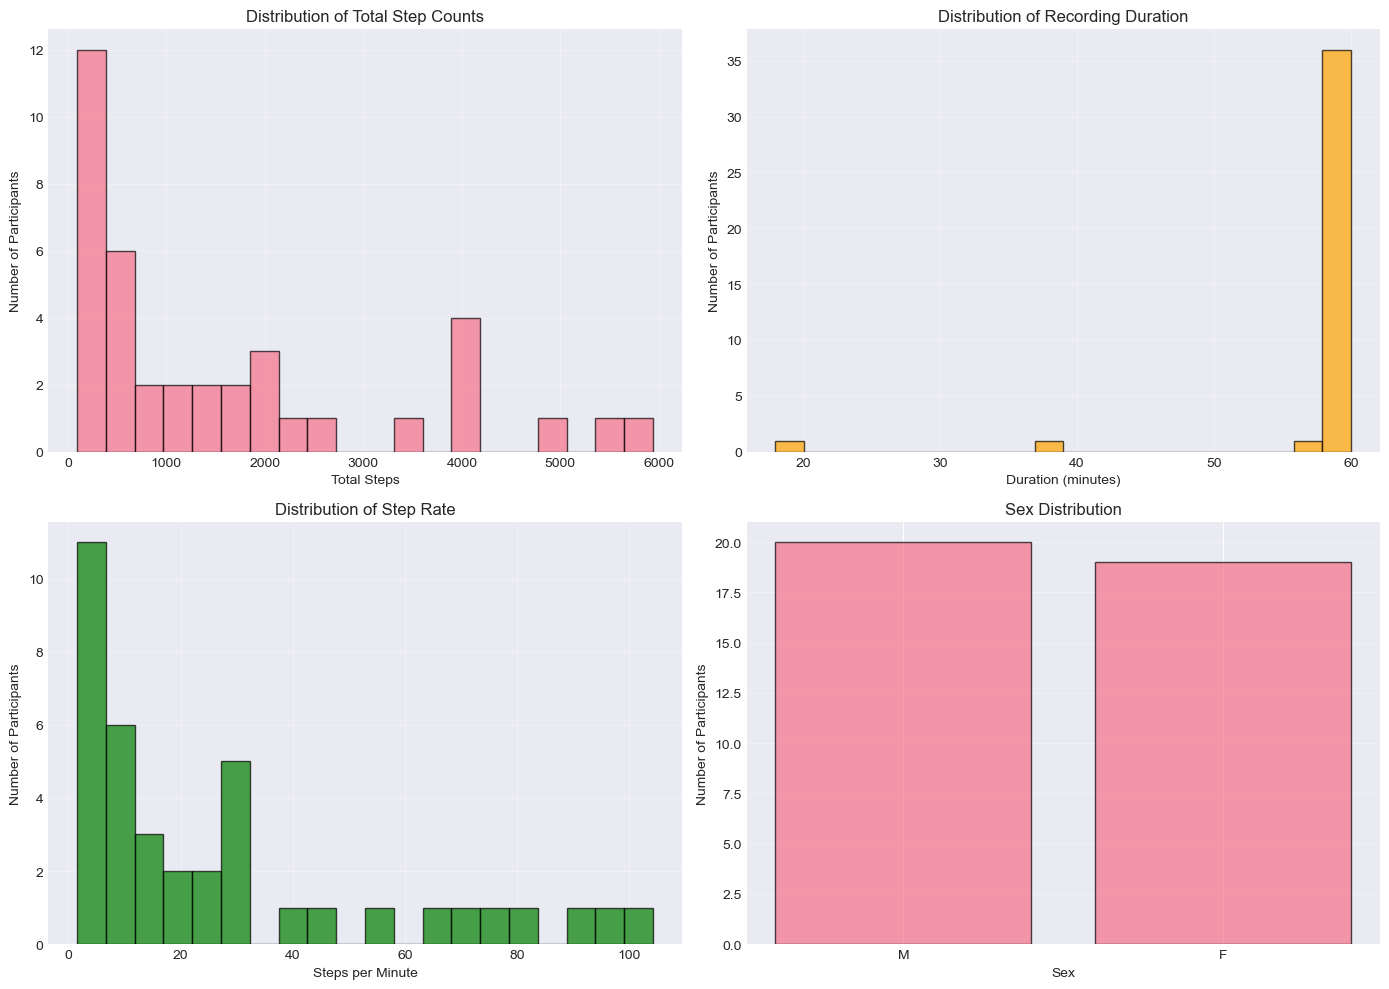

In [23]:
# Participant statistics visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Step count distribution
axes[0, 0].hist(stats_df['step_count'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Total Steps')
axes[0, 0].set_ylabel('Number of Participants')
axes[0, 0].set_title('Distribution of Total Step Counts')
axes[0, 0].grid(True, alpha=0.3)

# Recording duration
axes[0, 1].hist(stats_df['duration_sec'] / 60, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Duration (minutes)')
axes[0, 1].set_ylabel('Number of Participants')
axes[0, 1].set_title('Distribution of Recording Duration')
axes[0, 1].grid(True, alpha=0.3)

# Steps per minute
axes[1, 0].hist(stats_df['steps_per_min'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Steps per Minute')
axes[1, 0].set_ylabel('Number of Participants')
axes[1, 0].set_title('Distribution of Step Rate')
axes[1, 0].grid(True, alpha=0.3)

# Sex distribution
sex_counts = stats_df['sex'].value_counts()
axes[1, 1].bar(sex_counts.index, sex_counts.values, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Sex')
axes[1, 1].set_ylabel('Number of Participants')
axes[1, 1].set_title('Sex Distribution')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [24]:
# Summary statistics

print("\n=== Dataset Summary Statistics ===")
print(f"Total participants: {len(stats_df)}")
print(f"\nStep counts:")
print(f"  Mean: {stats_df['step_count'].mean():.1f}")
print(f"  Median: {stats_df['step_count'].median():.1f}")
print(f"  Min: {stats_df['step_count'].min():.0f}")
print(f"  Max: {stats_df['step_count'].max():.0f}")
print(f"\nRecording duration (minutes):")
print(f"  Mean: {stats_df['duration_sec'].mean() / 60:.1f}")
print(f"  Median: {stats_df['duration_sec'].median() / 60:.1f}")
print(f"\nStep rate (steps/min):")
print(f"  Mean: {stats_df['steps_per_min'].mean():.1f}")
print(f"  Median: {stats_df['steps_per_min'].median():.1f}")
print(f"\nSex distribution:")
print(stats_df['sex'].value_counts())
print(f"\nAge distribution:")
print(stats_df['age'].value_counts())


=== Dataset Summary Statistics ===
Total participants: 39

Step counts:
  Mean: 1612.9
  Median: 867.0
  Min: 94
  Max: 5939

Recording duration (minutes):
  Mean: 58.3
  Median: 60.0

Step rate (steps/min):
  Mean: 28.2
  Median: 14.5

Sex distribution:
sex
M    20
F    19
Name: count, dtype: int64

Age distribution:
age
19-30    13
45-81    13
31-44    13
Name: count, dtype: int64


In [ ]:
# Data quality check for all participants

print("\n=== Data Quality Checks for All Participants ===")

quality_issues = []
out_of_range_pids = []

for idx, row in metadata.iterrows():
    pid = row['participant']
    try:
        df = load_participant_data(pid)

        # Check for missing values
        missing_count = df.isnull().sum().sum()

        # Check accelerometer range (should be within ±8g)
        x_min, x_max = df['x'].min(), df['x'].max()
        y_min, y_max = df['y'].min(), df['y'].max()
        z_min, z_max = df['z'].min(), df['z'].max()

        out_of_range = (abs(x_min) > 8 or abs(x_max) > 8 or
                        abs(y_min) > 8 or abs(y_max) > 8 or
                        abs(z_min) > 8 or abs(z_max) > 8)

        # Check for zero or very low step counts
        step_count = df['annotation'].sum()
        duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
        steps_per_min = (step_count / duration) * 60 if duration > 0 else 0

        issues = []
        if missing_count > 0:
            issues.append(f"Missing values: {missing_count}")
        if out_of_range:
            issues.append(f"Out of range values")
            out_of_range_pids.append(pid)
        if step_count == 0:
            issues.append("No steps annotated")
        if steps_per_min < 5:
            issues.append(f"Very low step rate: {steps_per_min:.1f} steps/min")

        if issues or missing_count > 0:
            quality_issues.append({
                'participant': pid,
                'missing_values': missing_count,
                'x_range': f"[{x_min:.3f}, {x_max:.3f}]",
                'y_range': f"[{y_min:.3f}, {y_max:.3f}]",
                'z_range': f"[{z_min:.3f}, {z_max:.3f}]",
                'step_count': step_count,
                'steps_per_min': f"{steps_per_min:.1f}",
                'issues': '; '.join(issues) if issues else 'None'
            })

            print(f"\n{pid}:")
            print(f"  Missing values: {missing_count}")
            print(f"  X range: [{x_min:.3f}, {x_max:.3f}]")
            print(f"  Y range: [{y_min:.3f}, {y_max:.3f}]")
            print(f"  Z range: [{z_min:.3f}, {z_max:.3f}]")
            print(f"  Step count: {step_count}")
            print(f"  Steps per min: {steps_per_min:.1f}")
            if issues:
                print(f"  Issues: {'; '.join(issues)}")

    except Exception as e:
        print(f"\nError loading {pid}: {e}")
        quality_issues.append({
            'participant': pid,
            'missing_values': 'ERROR',
            'x_range': 'ERROR',
            'y_range': 'ERROR',
            'z_range': 'ERROR',
            'step_count': 'ERROR',
            'steps_per_min': 'ERROR',
            'issues': f'Failed to load: {e}'
        })

if quality_issues:
    print(f"\n\nSummary: {len(quality_issues)} participants with potential quality issues or anomalies")
    quality_df = pd.DataFrame(quality_issues)
    print(quality_df)
else:
    print("\n\nAll participants passed quality checks!")

print(f"\n\nParticipants with out of range accelerometer values (>±8g): {out_of_range_pids}")

The data description claims the accelerometer values ought to saturate after +-8G, but this limits seems to be crossed every now and then. Plot some of the overshooting XYZ accelerometer signals to see what the overshooting looks like.

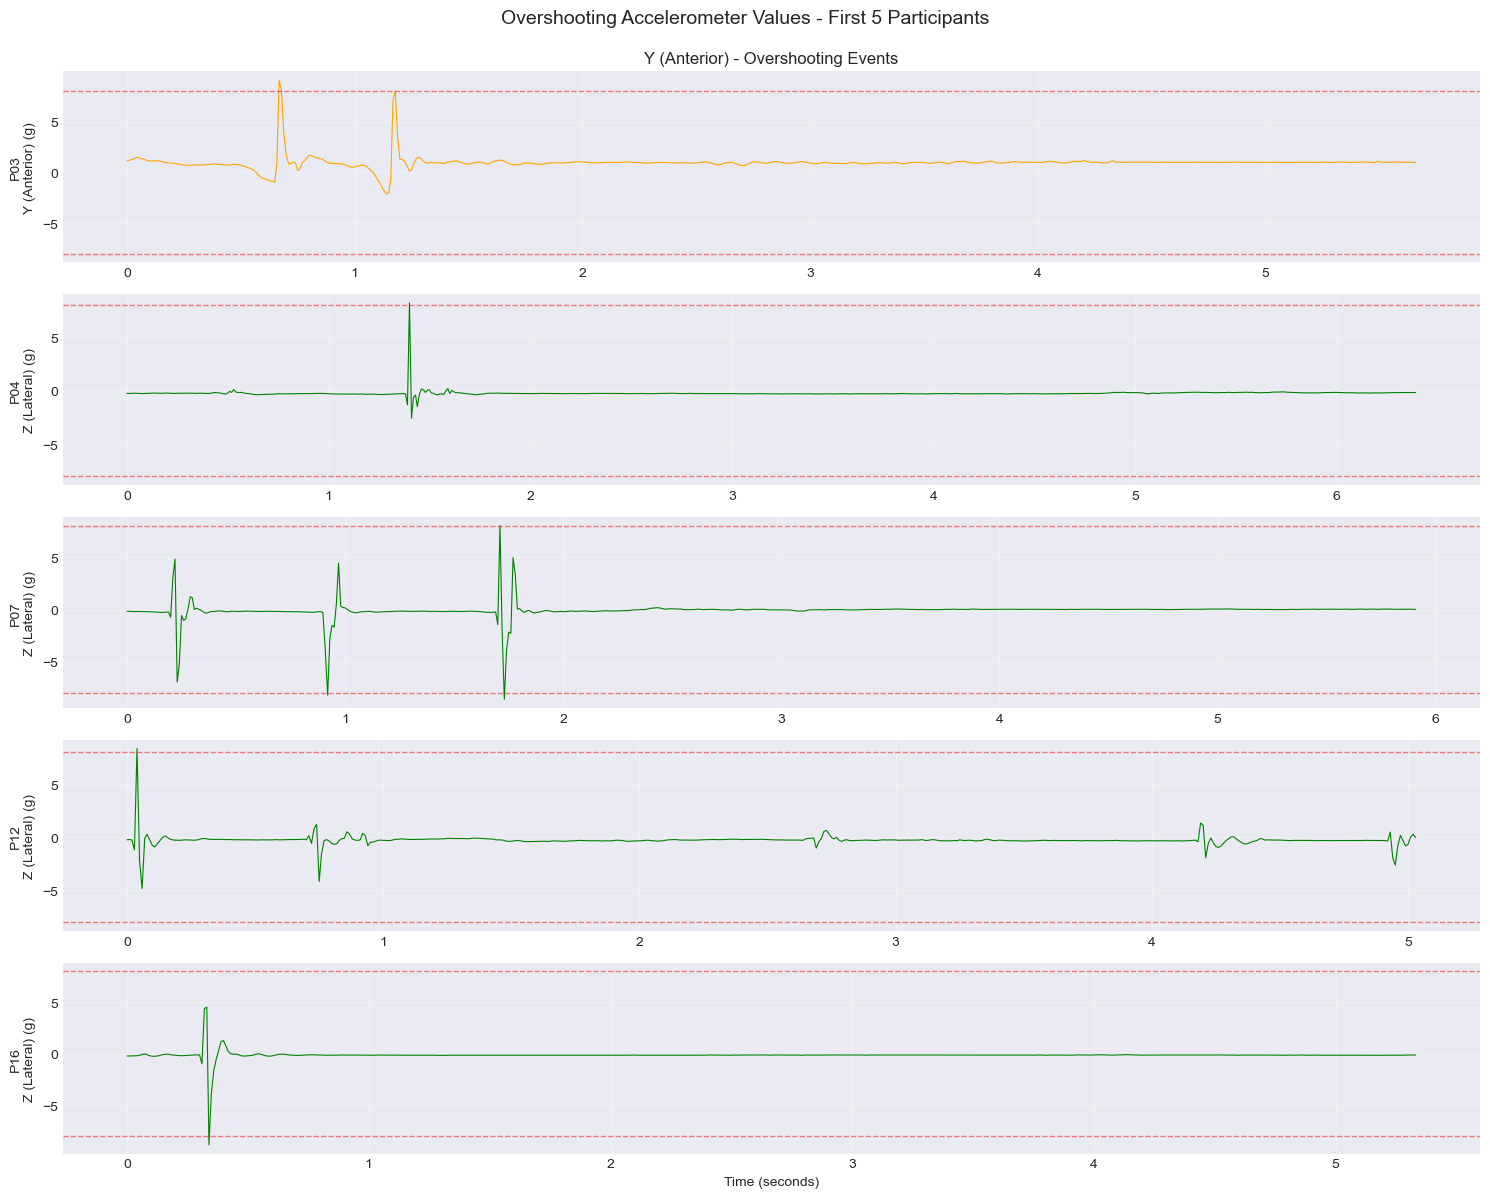

In [36]:
# Plot only the axis with overshooting values for first 5 participants

first_five_pids = out_of_range_pids[:5]

fig, axes = plt.subplots(len(first_five_pids), 1, figsize=(15, 12), sharex=False)
if len(first_five_pids) == 1:
    axes = [axes]

for i, pid in enumerate(first_five_pids):
    df = load_participant_data(pid)

    # Find which axis has overshooting and where it occurs
    x_exceed = (df['x'].abs() > 8)
    y_exceed = (df['y'].abs() > 8)
    z_exceed = (df['z'].abs() > 8)

    if x_exceed.any():
        exceed_idx = x_exceed.idxmax()
        axis_name = 'X (Superior)'
        axis_data = df['x']
        color = 'blue'
    elif y_exceed.any():
        exceed_idx = y_exceed.idxmax()
        axis_name = 'Y (Anterior)'
        axis_data = df['y']
        color = 'orange'
    elif z_exceed.any():
        exceed_idx = z_exceed.idxmax()
        axis_name = 'Z (Lateral)'
        axis_data = df['z']
        color = 'green'
    else:
        continue

    # Plot 10 second window around the overshooting point
    start_idx = max(0, exceed_idx - 500)
    end_idx = min(len(df), exceed_idx + 500)

    time_window = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
    window_time = time_window.iloc[start_idx:end_idx]

    axes[i].plot(window_time, axis_data.iloc[start_idx:end_idx], color=color, linewidth=0.8)
    axes[i].set_ylabel(f'{pid}\n{axis_name} (g)')
    axes[i].axhline(y=8, color='r', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].axhline(y=-8, color='r', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_title(f'{axis_name} - Overshooting Events')

axes[-1].set_xlabel('Time (seconds)')

plt.suptitle('Overshooting Accelerometer Values - First 5 Participants', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()


## Key Findings

- Some accelerometer values are over the saturation limits (+-8G)
- Step prevalence varies among participants
- No missing values, accelerometer readings mostly within expected range


